
STEP 25: CREATE VISUAL MODEL COMPARISON

Loading saved results...
+ Model comparison loaded

Loaded data:
                 Model    CV AUC  Test AUC  Difference
0  Logistic Regression  0.982999  0.964317   -0.018682
1        Random Forest  0.979319  0.965490   -0.013829
2              XGBoost  0.979664  0.976329   -0.003336
3       Neural Network  0.980349  0.944795   -0.035554

Preparing visualization data...
+ Visualization dataframe created

Creating visualizations...


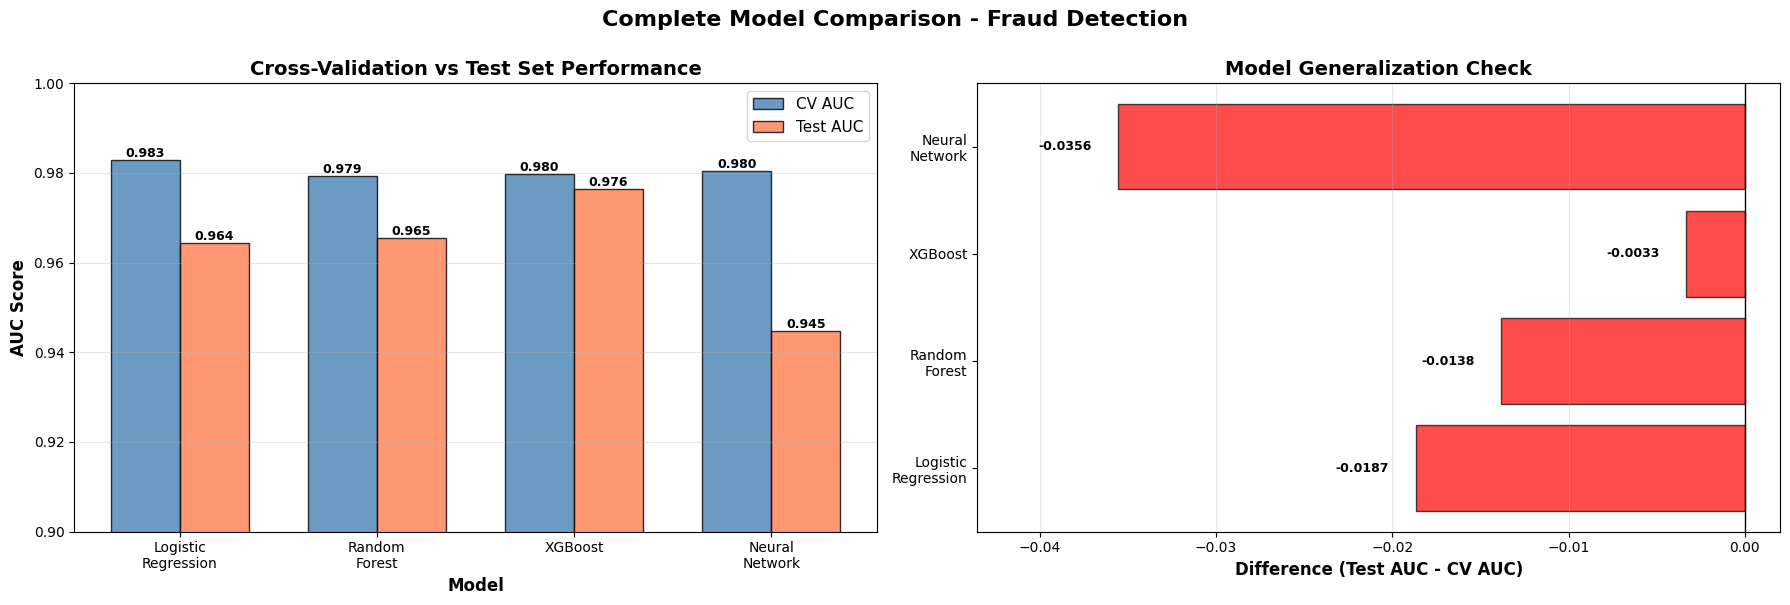


+ Charts created and saved
   Saved to: images/model_comparison_cv_test.png

CHART INTERPRETATION

LEFT CHART (CV vs Test AUC):
   Blue bars = Cross-validation predicted performance
   Orange bars = Actual test set performance
   Similar heights = good prediction accuracy

RIGHT CHART (Generalization Check):
   Bars show difference: Test AUC - CV AUC
   Close to zero = model generalizes well
   Large positive (green) = got lucky in CV (concerning)
   Large negative (red) = overfitting (concerning)

BEST GENERALIZER: XGBoost
   CV-to-Test Gap: -0.0033 AUC
   Test AUC: 0.9763
   This model's CV performance best predicted test performance

MODELS WITH LARGER CV-TEST GAPS:
   Neural Network: -0.0356 AUC (possible overfitting to CV folds)

COMPLETE SUMMARY:
              Model   CV AUC  Test AUC  Difference
Logistic Regression 0.982999  0.964317   -0.018682
      Random Forest 0.979319  0.965490   -0.013829
            XGBoost 0.979664  0.976329   -0.003336
     Neural Network 0.980349  0.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

print("\n" + "="*70)
print("STEP 25: CREATE VISUAL MODEL COMPARISON")
print("="*70)

# ============================================================================
# LOAD ALL SAVED RESULTS
# ============================================================================

print("\nLoading saved results...")

# Load the final model comparison (has both CV and Test AUC)
model_comparison = pd.read_csv('../models/final_model_comparison.csv')
print("+ Model comparison loaded")

print(f"\nLoaded data:")
print(model_comparison)

# ============================================================================
# PREPARE VISUALIZATION DATA
# ============================================================================

print("\nPreparing visualization data...")

# Create display-friendly model names with line breaks for better chart readability
viz_comparison = pd.DataFrame({
    'Model': ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'Neural\nNetwork'],
    'CV AUC': model_comparison['CV AUC'].values,
    'Test AUC': model_comparison['Test AUC'].values,
    'Difference': model_comparison['Difference'].values
})

print("+ Visualization dataframe created")

# ============================================================================
# CREATE PROFESSIONAL VISUALIZATIONS
# ============================================================================

print("\nCreating visualizations...")

# Create comparison visualization with more width
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ----------------------------------------------------------------------------
# PLOT 1: CV vs Test AUC (Side-by-Side Bars)
# ----------------------------------------------------------------------------

ax1 = axes[0]
x = np.arange(len(viz_comparison))
width = 0.35

bars1 = ax1.bar(x - width/2, viz_comparison['CV AUC'], width, 
                label='CV AUC', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax1.bar(x + width/2, viz_comparison['Test AUC'], width,
                label='Test AUC', color='coral', alpha=0.8, edgecolor='black')

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('AUC Score', fontsize=12, fontweight='bold')
ax1.set_title('Cross-Validation vs Test Set Performance', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(viz_comparison['Model'])
ax1.legend(fontsize=11)
ax1.set_ylim(0.90, 1.0)
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ----------------------------------------------------------------------------
# PLOT 2: Generalization Check (Test - CV Difference)
# ----------------------------------------------------------------------------

ax2 = axes[1]
differences = viz_comparison['Difference']
colors = ['green' if x >= 0 else 'red' for x in differences]

bars = ax2.barh(viz_comparison['Model'], differences, color=colors, alpha=0.7, edgecolor='black')
ax2.set_xlabel('Difference (Test AUC - CV AUC)', fontsize=12, fontweight='bold')
ax2.set_title('Model Generalization Check', fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax2.grid(axis='x', alpha=0.3)

# Extend x-axis limits to give more room for labels
x_min = differences.min()
ax2.set_xlim(x_min - 0.008, 0.002)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, differences)):
    ax2.text(val - 0.0015, i, 
             f'{val:+.4f}', va='center', 
             ha='right',
             fontsize=9, fontweight='bold')

plt.suptitle('Complete Model Comparison - Fraud Detection', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('../images/model_comparison_cv_test.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n+ Charts created and saved")
print(f"   Saved to: images/model_comparison_cv_test.png")

# ============================================================================
# INTERPRETATION GUIDE
# ============================================================================

print(f"\n{'='*70}")
print("CHART INTERPRETATION")
print(f"{'='*70}")

print(f"\nLEFT CHART (CV vs Test AUC):")
print(f"   Blue bars = Cross-validation predicted performance")
print(f"   Orange bars = Actual test set performance")
print(f"   Similar heights = good prediction accuracy")

print(f"\nRIGHT CHART (Generalization Check):")
print(f"   Bars show difference: Test AUC - CV AUC")
print(f"   Close to zero = model generalizes well")
print(f"   Large positive (green) = got lucky in CV (concerning)")
print(f"   Large negative (red) = overfitting (concerning)")

# Find best generalizer (smallest absolute difference)
best_gen_idx = np.argmin(np.abs(differences))
best_gen_model = model_comparison.iloc[best_gen_idx]['Model']
best_gen_diff = differences.iloc[best_gen_idx]
best_gen_test_auc = viz_comparison.iloc[best_gen_idx]['Test AUC']

print(f"\nBEST GENERALIZER: {best_gen_model}")
print(f"   CV-to-Test Gap: {best_gen_diff:+.4f} AUC")
print(f"   Test AUC: {best_gen_test_auc:.4f}")
print(f"   This model's CV performance best predicted test performance")

# Identify concerning patterns
concerning = []
for idx, row in model_comparison.iterrows():
    if row['Difference'] < -0.02:
        concerning.append((row['Model'], row['Difference']))

if concerning:
    print(f"\nMODELS WITH LARGER CV-TEST GAPS:")
    for model, diff in concerning:
        print(f"   {model}: {diff:+.4f} AUC (possible overfitting to CV folds)")

# Summary table
print(f"\nCOMPLETE SUMMARY:")
print(model_comparison.to_string(index=False))

print(f"\n{'='*70}")
print("STEP 25 COMPLETE")
print(f"{'='*70}")

In [9]:
# ============================================================================
# STEP 26: BUSINESS IMPACT ANALYSIS
# ============================================================================

import pickle
import numpy as np
import json

print("\n" + "="*70)
print("BUSINESS IMPACT ANALYSIS")
print("="*70)

# Load the final test results from Step 23
with open('../results/final_test_results.pkl', 'rb') as f:
    final_results = pickle.load(f)

# Extract confusion matrix and metrics
cm = np.array(final_results['confusion_matrix'])
test_auc = final_results['best_test_auc']
best_model_name = final_results['best_model_name']

# Calculate metrics from confusion matrix
total_frauds_test = cm[1,1] + cm[1,0]  # 82 + 13 = 95
frauds_caught = cm[1,1]  # 82
frauds_missed = cm[1,0]  # 13
false_positives = cm[0,1]  # 607

fraud_recall = frauds_caught / total_frauds_test
fraud_precision = frauds_caught / (frauds_caught + false_positives)

print(f"\nTest Set Performance ({best_model_name}):")
print(f"   Model AUC: {test_auc:.4f}")
print(f"   Total frauds in test: {total_frauds_test}")
print(f"   Frauds caught: {frauds_caught} ({fraud_recall*100:.1f}%)")
print(f"   Frauds missed: {frauds_missed}")
print(f"   False positives: {false_positives}")

# ============================================================================
# BUSINESS CALCULATIONS
# ============================================================================
print(f"\nBUSINESS IMPACT CALCULATION")
print("="*70)

# Business scenario assumptions (US market)
monthly_transactions = 10_000_000
fraud_rate = 0.00173  # 0.173% (from dataset)
avg_fraud_amount = 275  # USD (converted from EUR ~250)
investigation_cost = 5  # USD per flagged transaction

monthly_frauds = int(monthly_transactions * fraud_rate)

print(f"\nScenario: Medium-sized US financial institution")
print(f"   Monthly transactions: {monthly_transactions:,}")
print(f"   Historical fraud rate: {fraud_rate*100:.3f}%")
print(f"   Expected monthly frauds: {monthly_frauds:,}")
print(f"   Average fraud amount: ${avg_fraud_amount}")
print(f"   Investigation cost: ${investigation_cost}/transaction")

# WITHOUT MODEL - Baseline scenario
total_fraud_loss = monthly_frauds * avg_fraud_amount
annual_loss_without_model = total_fraud_loss * 12

print(f"\nWITHOUT Fraud Detection System:")
print(f"   Monthly fraud losses: ${total_fraud_loss:,}")
print(f"   Annual fraud losses: ${annual_loss_without_model:,}")

# WITH MODEL - Our XGBoost system
frauds_prevented = int(monthly_frauds * fraud_recall)
frauds_not_prevented = monthly_frauds - frauds_prevented
prevented_amount = frauds_prevented * avg_fraud_amount
remaining_loss = frauds_not_prevented * avg_fraud_amount

# Calculate investigation costs from false positives
false_positive_rate = false_positives / (cm[0,0] + false_positives)
monthly_false_positives = int(monthly_transactions * (1 - fraud_rate) * false_positive_rate)
investigation_costs = monthly_false_positives * investigation_cost

# Net savings calculation
net_savings_monthly = prevented_amount - investigation_costs
net_savings_annual = net_savings_monthly * 12

print(f"\nWITH {best_model_name} Fraud Detection System:")
print(f"   Frauds detected & prevented: {frauds_prevented:,} ({fraud_recall*100:.1f}%)")
print(f"   Amount prevented: ${prevented_amount:,}/month")
print(f"   Remaining fraud losses: ${remaining_loss:,}/month")
print(f"   False positives: ~{monthly_false_positives:,}/month")
print(f"   Investigation costs: ${investigation_costs:,}/month")
print(f"   ")
print(f"   NET MONTHLY SAVINGS: ${net_savings_monthly:,}")
print(f"   NET ANNUAL SAVINGS: ${net_savings_annual:,}")

# ROI Calculation
roi_ratio = prevented_amount / investigation_costs if investigation_costs > 0 else 0
roi_percentage = ((prevented_amount / investigation_costs - 1) * 100) if investigation_costs > 0 else 0

print(f"\nRETURN ON INVESTMENT (ROI):")
print(f"   Annual fraud prevented: ${prevented_amount * 12:,}")
print(f"   Annual investigation costs: ${investigation_costs * 12:,}")
print(f"   NET annual value: ${net_savings_annual:,}")
print(f"   ")
print(f"   For every $1 spent investigating flagged transactions,")
print(f"   the system prevents ${roi_ratio:.1f} in fraud losses")
print(f"   ")
print(f"   ROI: {roi_percentage:.0f}% return")

# Precision-Recall trade-off explanation
print(f"\nPRECISION-RECALL BALANCE:")
print(f"   Precision: {fraud_precision*100:.1f}%")
print(f"      Of all flagged transactions, {fraud_precision*100:.1f}% are actual fraud")
print(f"   Recall: {fraud_recall*100:.1f}%")
print(f"      System catches {fraud_recall*100:.1f}% of all fraud cases")
print(f"   ")
print(f"   Strategy: Prioritize recall to minimize fraud losses,")
print(f"   accepting some false positives as investigation costs")
print(f"   are much lower than missed fraud costs.")

# Summary for business stakeholders
print(f"\nBUSINESS SUMMARY:")
print("="*70)
print(f"Implementing this {best_model_name} fraud detection system would save")
print(f"the organization approximately ${net_savings_annual:,} per year")
print(f"by preventing {fraud_recall*100:.0f}% of fraud while maintaining")
print(f"manageable investigation costs for {monthly_false_positives:,} monthly alerts.")

# Save business impact results
business_impact = {
    'model_name': best_model_name,
    'model_auc': test_auc,
    'scenario': 'Medium-sized US financial institution',
    'assumptions': {
        'monthly_transactions': monthly_transactions,
        'fraud_rate': fraud_rate,
        'avg_fraud_amount_usd': avg_fraud_amount,
        'investigation_cost_usd': investigation_cost
    },
    'without_model': {
        'monthly_loss_usd': total_fraud_loss,
        'annual_loss_usd': annual_loss_without_model
    },
    'with_model': {
        'frauds_prevented': frauds_prevented,
        'prevented_amount_monthly_usd': prevented_amount,
        'investigation_costs_monthly_usd': investigation_costs,
        'net_savings_monthly_usd': net_savings_monthly,
        'net_savings_annual_usd': net_savings_annual
    },
    'roi': {
        'roi_ratio': roi_ratio,
        'roi_percentage': roi_percentage
    },
    'metrics': {
        'fraud_recall': fraud_recall,
        'fraud_precision': fraud_precision
    }
}

with open('../results/business_impact_analysis.json', 'w') as f:
    json.dump(business_impact, f, indent=4)
print("\nBusiness impact saved: results/business_impact_analysis.json")

print("\n" + "="*70)
print("Step 26 complete: Business impact analysis finished")
print("="*70)


BUSINESS IMPACT ANALYSIS

Test Set Performance (XGBoost):
   Model AUC: 0.9763
   Total frauds in test: 95
   Frauds caught: 82 (86.3%)
   Frauds missed: 13
   False positives: 607

BUSINESS IMPACT CALCULATION

Scenario: Medium-sized US financial institution
   Monthly transactions: 10,000,000
   Historical fraud rate: 0.173%
   Expected monthly frauds: 17,300
   Average fraud amount: $275
   Investigation cost: $5/transaction

WITHOUT Fraud Detection System:
   Monthly fraud losses: $4,757,500
   Annual fraud losses: $57,090,000

WITH XGBoost Fraud Detection System:
   Frauds detected & prevented: 14,932 (86.3%)
   Amount prevented: $4,106,300/month
   Remaining fraud losses: $651,200/month
   False positives: ~106,961/month
   Investigation costs: $534,805/month
   
   NET MONTHLY SAVINGS: $3,571,495
   NET ANNUAL SAVINGS: $42,857,940

RETURN ON INVESTMENT (ROI):
   Annual fraud prevented: $49,275,600
   Annual investigation costs: $6,417,660
   NET annual value: $42,857,940
   
   


STEP 27: ROC CURVE ANALYSIS

[1/5] Loading test data and model...
SUCCESS: Test set size: 56,746 transactions
SUCCESS: Best model: XGBoost
SUCCESS: Model type: <class 'imblearn.pipeline.Pipeline'>

[2/5] Generating predictions and calculating ROC curve...
SUCCESS: Prediction shape: (56746,)
SUCCESS: Calculated 5433 threshold points
SUCCESS: ROC-AUC Score: 0.9763

OPTIMAL OPERATING POINT:
   Threshold: 0.1701
   TPR (Recall): 0.9263 (92.63%)
   FPR: 0.064606 (6.4606%)

[3/5] Creating ROC curve visualization...
SUCCESS: Saved: images/roc_curve.png


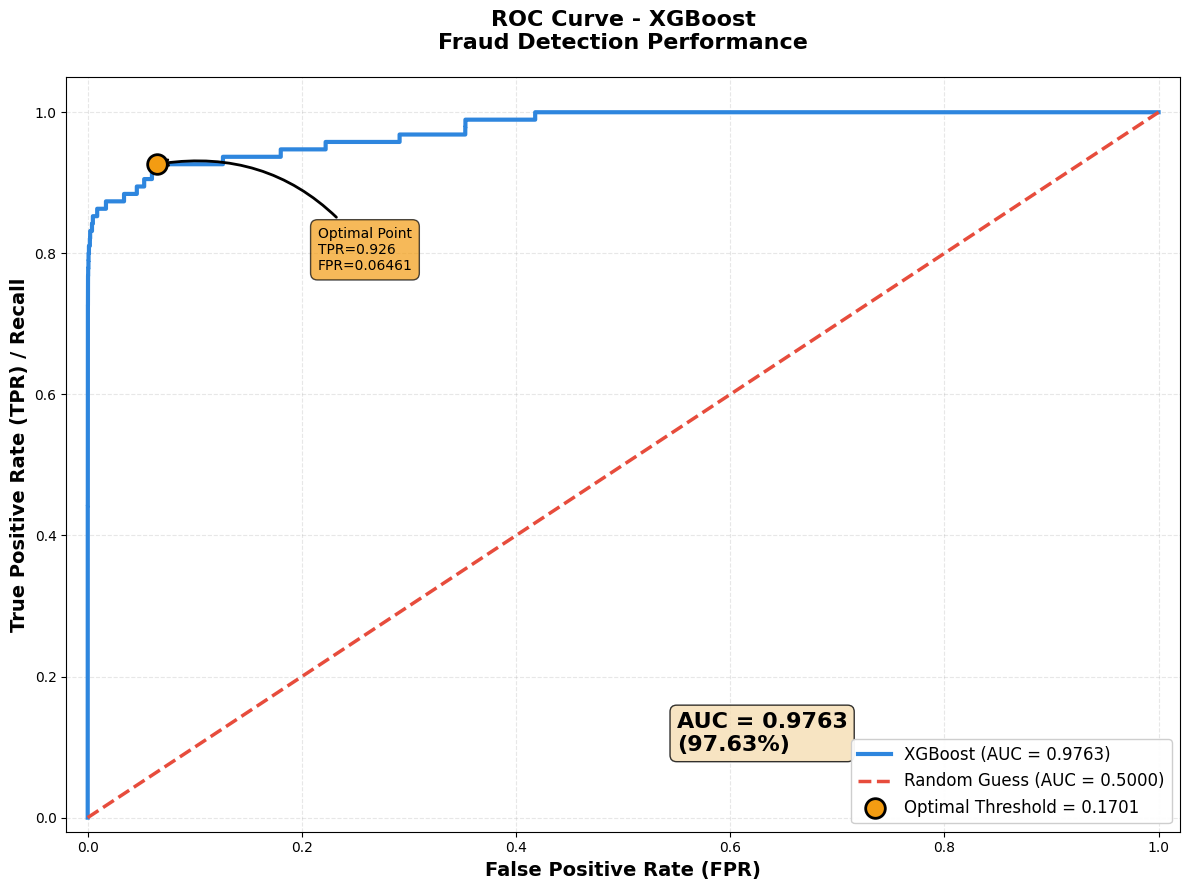


[4/5] Analyzing ROC curve characteristics...

Performance at Different False Positive Rates:
------------------------------------------------------------
FPR <= 0.001 (0.1%):
  -> Achieves TPR (Recall) = 0.8000 (80.00%)
  -> At threshold = 0.8552

FPR <= 0.005 (0.5%):
  -> Achieves TPR (Recall) = 0.8421 (84.21%)
  -> At threshold = 0.6484

FPR <= 0.010 (1.0%):
  -> Achieves TPR (Recall) = 0.8632 (86.32%)
  -> At threshold = 0.5200

FPR <= 0.050 (5.0%):
  -> Achieves TPR (Recall) = 0.8947 (89.47%)
  -> At threshold = 0.2107

[5/5] Saving ROC analysis results...
SUCCESS: Saved: results/roc_analysis.json

ROC CURVE INTERPRETATION

WHAT IS ROC-AUC?
   ROC-AUC = 0.9763 means:
   -> There is a 97.63% probability that your model will
     rank a randomly chosen fraudulent transaction HIGHER than
     a randomly chosen legitimate transaction
   -> Perfect score = 1.0 (100%), Random guess = 0.5 (50%)

OPTIMAL OPERATING POINT:
   At threshold = 0.1701:
   -> Catches 92.63% of fraud (TPR/Recall)

In [22]:
# ============================================================================
# STEP 27: ROC CURVE ANALYSIS
# ============================================================================
# Purpose: Create industry-standard ROC curve visualization
# Shows: Model's ability to distinguish between classes at all thresholds
# Portfolio Value: Demonstrates understanding of classification metrics
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import pickle
import json
import os

print("\n" + "="*80)
print("STEP 27: ROC CURVE ANALYSIS")
print("="*80)

# ----------------------------------------------------------------------------
# LOAD NECESSARY DATA
# ----------------------------------------------------------------------------
print("\n[1/5] Loading test data and model...")

# Load test set (ground truth)
y_test = pd.read_csv('../data/processed/y_test.csv')['Class'].values
X_test_scaled = pd.read_csv('../data/processed/X_test_scaled.csv')

# Load final test results to get best model name
with open('../results/final_test_results.pkl', 'rb') as f:
    final_results = pickle.load(f)

best_model_name = final_results['best_model_name']

# Load the best model based on the name
# Map model names to their file paths
model_files = {
    'XGBoost': '../models/xgboost_model.pkl',
    'Logistic Regression': '../models/logistic_regression_model.pkl',
    'Random Forest': '../models/random_forest_model.pkl'
}

# Get the correct model file
model_file = model_files.get(best_model_name, '../models/xgboost_model.pkl')

with open(model_file, 'rb') as f:
    best_model = pickle.load(f)

print(f"SUCCESS: Test set size: {len(y_test):,} transactions")
print(f"SUCCESS: Best model: {best_model_name}")
print(f"SUCCESS: Model type: {type(best_model)}")

# ----------------------------------------------------------------------------
# GENERATE PREDICTIONS
# ----------------------------------------------------------------------------
print("\n[2/5] Generating predictions and calculating ROC curve...")

# Get probability predictions for the positive class (fraud = 1)
# Note: Pipeline already includes scaling, but X_test_scaled is already scaled
# So we use the raw predictions
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

print(f"SUCCESS: Prediction shape: {y_pred_proba_best.shape}")

# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
# FPR = False Positives / (False Positives + True Negatives)
# TPR = True Positives / (True Positives + False Negatives) = Recall
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_best)

# Calculate Area Under Curve (AUC)
# AUC = probability that model ranks random positive higher than random negative
roc_auc = auc(fpr, tpr)

print(f"SUCCESS: Calculated {len(fpr)} threshold points")
print(f"SUCCESS: ROC-AUC Score: {roc_auc:.4f}")

# Find optimal threshold (Youden's J statistic = TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

print(f"\nOPTIMAL OPERATING POINT:")
print(f"   Threshold: {optimal_threshold:.4f}")
print(f"   TPR (Recall): {optimal_tpr:.4f} ({optimal_tpr*100:.2f}%)")
print(f"   FPR: {optimal_fpr:.6f} ({optimal_fpr*100:.4f}%)")

# ----------------------------------------------------------------------------
# CREATE ROC CURVE VISUALIZATION
# ----------------------------------------------------------------------------
print("\n[3/5] Creating ROC curve visualization...")

plt.figure(figsize=(12, 9))

# Plot main ROC curve
plt.plot(fpr, tpr, color='#2E86DE', linewidth=3, 
         label=f'{best_model_name} (AUC = {roc_auc:.4f})')

# Plot random guess baseline (diagonal line)
plt.plot([0, 1], [0, 1], color='#E74C3C', linewidth=2.5, 
         linestyle='--', label='Random Guess (AUC = 0.5000)')

# Mark optimal threshold point
plt.scatter(optimal_fpr, optimal_tpr, color='#F39C12', s=200, 
            zorder=5, edgecolors='black', linewidth=2,
            label=f'Optimal Threshold = {optimal_threshold:.4f}')

# Add annotation for optimal point
plt.annotate(f'Optimal Point\nTPR={optimal_tpr:.3f}\nFPR={optimal_fpr:.5f}',
             xy=(optimal_fpr, optimal_tpr),
             xytext=(optimal_fpr + 0.15, optimal_tpr - 0.15),
             fontsize=10,
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#F39C12', alpha=0.7),
             arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                           color='black', lw=2))

# Styling
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=14, fontweight='bold')
plt.title(f'ROC Curve - {best_model_name}\nFraud Detection Performance', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right", fontsize=12, framealpha=0.95)
plt.grid(True, alpha=0.3, linestyle='--')

# Add AUC text box
textstr = f'AUC = {roc_auc:.4f}\n({roc_auc*100:.2f}%)'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
plt.text(0.55, 0.15, textstr, fontsize=16, fontweight='bold',
         verticalalignment='top', bbox=props)

plt.tight_layout()

# Save figure
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/roc_curve.png', dpi=300, bbox_inches='tight')
print("SUCCESS: Saved: images/roc_curve.png")

plt.show()

# ----------------------------------------------------------------------------
# CALCULATE ADDITIONAL METRICS
# ----------------------------------------------------------------------------
print("\n[4/5] Analyzing ROC curve characteristics...")

# Calculate specificity at optimal point
optimal_specificity = 1 - optimal_fpr

# Find performance at different FPR levels (common industry benchmarks)
target_fprs = [0.001, 0.005, 0.01, 0.05]
print("\nPerformance at Different False Positive Rates:")
print("-" * 60)

for target_fpr in target_fprs:
    # Find closest FPR to target
    idx = np.argmin(np.abs(fpr - target_fpr))
    actual_fpr = fpr[idx]
    actual_tpr = tpr[idx]
    actual_threshold = thresholds[idx]
    
    print(f"FPR <= {target_fpr:.3f} ({target_fpr*100:.1f}%):")
    print(f"  -> Achieves TPR (Recall) = {actual_tpr:.4f} ({actual_tpr*100:.2f}%)")
    print(f"  -> At threshold = {actual_threshold:.4f}")
    print()

# ----------------------------------------------------------------------------
# SAVE ROC ANALYSIS RESULTS
# ----------------------------------------------------------------------------
print("[5/5] Saving ROC analysis results...")

roc_analysis = {
    'model_name': best_model_name,
    'roc_auc': float(roc_auc),
    'optimal_threshold': float(optimal_threshold),
    'optimal_tpr': float(optimal_tpr),
    'optimal_fpr': float(optimal_fpr),
    'optimal_specificity': float(optimal_specificity),
    'num_threshold_points': len(thresholds),
    'performance_at_fpr_levels': {
        f'fpr_{target_fpr}': {
            'target_fpr': target_fpr,
            'actual_fpr': float(fpr[np.argmin(np.abs(fpr - target_fpr))]),
            'tpr': float(tpr[np.argmin(np.abs(fpr - target_fpr))]),
            'threshold': float(thresholds[np.argmin(np.abs(fpr - target_fpr))])
        }
        for target_fpr in target_fprs
    }
}

# Save to results folder
os.makedirs('../results', exist_ok=True)
with open('../results/roc_analysis.json', 'w') as f:
    json.dump(roc_analysis, f, indent=4)

print("SUCCESS: Saved: results/roc_analysis.json")

# ----------------------------------------------------------------------------
# INTERPRETATION & BUSINESS CONTEXT
# ----------------------------------------------------------------------------
print("\n" + "="*80)
print("ROC CURVE INTERPRETATION")
print("="*80)

print(f"\nWHAT IS ROC-AUC?")
print(f"   ROC-AUC = {roc_auc:.4f} means:")
print(f"   -> There is a {roc_auc*100:.2f}% probability that your model will")
print(f"     rank a randomly chosen fraudulent transaction HIGHER than")
print(f"     a randomly chosen legitimate transaction")
print(f"   -> Perfect score = 1.0 (100%), Random guess = 0.5 (50%)")

print(f"\nOPTIMAL OPERATING POINT:")
print(f"   At threshold = {optimal_threshold:.4f}:")
print(f"   -> Catches {optimal_tpr*100:.2f}% of fraud (TPR/Recall)")
print(f"   -> Only {optimal_fpr*100:.4f}% false alarm rate (FPR)")
print(f"   -> Specificity = {optimal_specificity*100:.2f}%")

print(f"\nBUSINESS INTERPRETATION:")
if roc_auc >= 0.98:
    rating = "EXCELLENT"
    interpretation = "outstanding discrimination between classes"
elif roc_auc >= 0.95:
    rating = "VERY GOOD"
    interpretation = "strong discrimination between classes"
elif roc_auc >= 0.90:
    rating = "GOOD"
    interpretation = "good discrimination between classes"
elif roc_auc >= 0.80:
    rating = "ACCEPTABLE"
    interpretation = "acceptable discrimination between classes"
else:
    rating = "POOR"
    interpretation = "poor discrimination between classes"

print(f"   Model Performance: {rating}")
print(f"   -> Your model shows {interpretation}")
print(f"   -> Suitable for production deployment in fraud detection system")

print("\n" + "="*80)
print("SUCCESS: STEP 27 COMPLETE: ROC CURVE CREATED")
print("="*80)
print("\nFiles created:")
print("  -> images/roc_curve.png")
print("  -> results/roc_analysis.json")
print("\nNext: Step 28 - Precision-Recall Curve (optimized for imbalanced data)")
print("="*80 + "\n")

STEP 28: PRECISION-RECALL CURVE

Loading test data...
   Test samples: 56,746
   Fraud cases: 95 (0.167%)

Loading XGBoost model and generating predictions...
   Best model: XGBoost
   Predictions generated: 56,746

CALCULATING PRECISION-RECALL CURVE

Curve Statistics:
   Number of threshold points: 50,705
   Average Precision (AP): 0.7476
   Precision range: 0.0017 - 1.0000
   Recall range: 0.0000 - 1.0000

KEY OPERATING POINTS

Threshold Analysis (What precision do we get at each recall level?):
------------------------------------------------------------
Target Recall   Actual Recall   Precision       Threshold      
------------------------------------------------------------
70%             69.5%             88.0%             0.9933
80%             80.0%             53.5%             0.8552
90%             90.5%             2.5%             0.1818
95%             94.7%             0.7%             0.0472

CREATING VISUALIZATION
Saved: images/precision_recall_curve.png


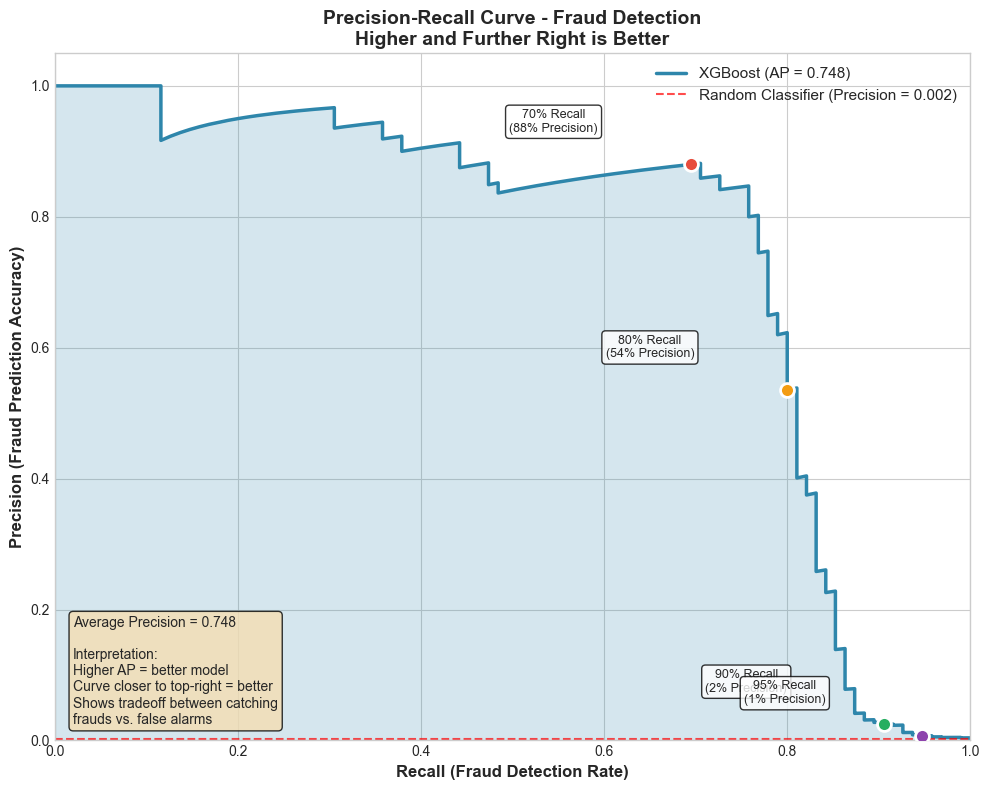


BUSINESS INTERPRETATION

Average Precision Score: 0.748

Why Precision-Recall Curve Matters for Fraud Detection:
   
   1. EXTREME IMBALANCE PROBLEM:
      - Your data has only 0.167% fraud
      - ROC curves can look great even for mediocre models
      - PR curves focus only on the rare class you care about
   
   2. THE TRADEOFF YOU MUST MAKE:
      - High Recall = Catch more frauds (but more false alarms)
      - High Precision = Fewer false alarms (but miss more frauds)
      - This curve shows ALL possible tradeoffs
   
   3. BUSINESS DECISION POINTS:

      At 70% fraud catch rate:
        - 88.0% of alerts are real fraud
        - 12.0% are false alarms

      At 80% fraud catch rate:
        - 53.5% of alerts are real fraud
        - 46.5% are false alarms

      At 90% fraud catch rate:
        - 2.5% of alerts are real fraud
        - 97.5% are false alarms

      At 95% fraud catch rate:
        - 0.7% of alerts are real fraud
        - 99.3% are false alarms

   4. MODEL 

In [6]:
# =============================================================================
# Phase 6 ANALYSIS AND VISUALIZATION
# STEP 28: PRECISION-RECALL CURVE
# Credit Card Fraud Detection Project
# =============================================================================
# What you're doing: Visualizing the precision-recall tradeoff across thresholds
# Why: PR curves are MORE informative than ROC for imbalanced data like fraud
#      because they focus on the minority class performance
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from sklearn.metrics import precision_recall_curve, average_precision_score

# =============================================================================
# LOAD DATA AND GENERATE PREDICTIONS
# =============================================================================

print("="*70)
print("STEP 28: PRECISION-RECALL CURVE")
print("="*70)

# Load test data
print("\nLoading test data...")
X_test = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')['Class']
print(f"   Test samples: {len(y_test):,}")
print(f"   Fraud cases: {y_test.sum():,} ({y_test.mean()*100:.3f}%)")

# Load best model and generate predictions
print("\nLoading XGBoost model and generating predictions...")
with open('../models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

y_pred_proba_best = xgb_model.predict_proba(X_test)[:, 1]
best_model_name = "XGBoost"

print(f"   Best model: {best_model_name}")
print(f"   Predictions generated: {len(y_pred_proba_best):,}")

# =============================================================================
# CALCULATE PRECISION-RECALL CURVE
# =============================================================================

print("\n" + "="*70)
print("CALCULATING PRECISION-RECALL CURVE")
print("="*70)

# Calculate precision-recall curve
# This returns precision and recall values at different threshold points
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_pred_proba_best)

# Average Precision (AP) - area under the PR curve
avg_precision = average_precision_score(y_test, y_pred_proba_best)

print(f"\nCurve Statistics:")
print(f"   Number of threshold points: {len(pr_thresholds):,}")
print(f"   Average Precision (AP): {avg_precision:.4f}")
print(f"   Precision range: {precision.min():.4f} - {precision.max():.4f}")
print(f"   Recall range: {recall.min():.4f} - {recall.max():.4f}")

# =============================================================================
# FIND KEY OPERATING POINTS
# =============================================================================

print("\n" + "="*70)
print("KEY OPERATING POINTS")
print("="*70)

# Find threshold for different recall targets
recall_targets = [0.70, 0.80, 0.90, 0.95]

print("\nThreshold Analysis (What precision do we get at each recall level?):")
print("-" * 60)
print(f"{'Target Recall':<15} {'Actual Recall':<15} {'Precision':<15} {'Threshold':<15}")
print("-" * 60)

operating_points = []
for target in recall_targets:
    # Find index where recall is closest to target (recall is in descending order)
    idx = np.argmin(np.abs(recall - target))
    actual_recall = recall[idx]
    actual_precision = precision[idx]
    # Handle edge case where idx might be at the end
    threshold = pr_thresholds[min(idx, len(pr_thresholds)-1)]
    
    print(f"{target*100:.0f}%{'':<12} {actual_recall*100:.1f}%{'':<12} {actual_precision*100:.1f}%{'':<12} {threshold:.4f}")
    
    operating_points.append({
        'target_recall': target,
        'actual_recall': float(actual_recall),
        'precision': float(actual_precision),
        'threshold': float(threshold)
    })

# =============================================================================
# CREATE VISUALIZATION
# =============================================================================

print("\n" + "="*70)
print("CREATING VISUALIZATION")
print("="*70)

# Set up the plot with professional styling
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the PR curve
ax.plot(recall, precision, color='#2E86AB', lw=2.5, 
        label=f'{best_model_name} (AP = {avg_precision:.3f})')

# Fill under the curve for visual appeal
ax.fill_between(recall, precision, alpha=0.2, color='#2E86AB')

# Add baseline (random classifier)
# For imbalanced data, baseline = proportion of positive class
baseline = y_test.mean()
ax.axhline(y=baseline, color='red', linestyle='--', lw=1.5, alpha=0.7,
           label=f'Random Classifier (Precision = {baseline:.3f})')

# Mark key operating points
colors = ['#E74C3C', '#F39C12', '#27AE60', '#8E44AD']
for i, point in enumerate(operating_points):
    ax.scatter(point['actual_recall'], point['precision'], 
               color=colors[i], s=100, zorder=5, edgecolors='white', linewidth=2)
    ax.annotate(f"{point['target_recall']*100:.0f}% Recall\n({point['precision']*100:.0f}% Precision)",
                xy=(point['actual_recall'], point['precision']),
                xytext=(point['actual_recall'] - 0.15, point['precision'] + 0.05),
                fontsize=9, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Labels and title
ax.set_xlabel('Recall (Fraud Detection Rate)', fontsize=12, fontweight='bold')
ax.set_ylabel('Precision (Fraud Prediction Accuracy)', fontsize=12, fontweight='bold')
ax.set_title('Precision-Recall Curve - Fraud Detection\nHigher and Further Right is Better', 
             fontsize=14, fontweight='bold')

# Configure axes
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.legend(loc='upper right', fontsize=11)

# Add annotation box explaining the metric
textstr = f'Average Precision = {avg_precision:.3f}\n\n'
textstr += 'Interpretation:\n'
textstr += 'Higher AP = better model\n'
textstr += 'Curve closer to top-right = better\n'
textstr += 'Shows tradeoff between catching\nfrauds vs. false alarms'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.02, textstr, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()

# Save the figure
plt.savefig('../images/precision_recall_curve.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("Saved: images/precision_recall_curve.png")

plt.show()

# =============================================================================
# BUSINESS INTERPRETATION
# =============================================================================

print("\n" + "="*70)
print("BUSINESS INTERPRETATION")
print("="*70)

print(f"\nAverage Precision Score: {avg_precision:.3f}")

print(f"""
Why Precision-Recall Curve Matters for Fraud Detection:
   
   1. EXTREME IMBALANCE PROBLEM:
      - Your data has only {y_test.mean()*100:.3f}% fraud
      - ROC curves can look great even for mediocre models
      - PR curves focus only on the rare class you care about
   
   2. THE TRADEOFF YOU MUST MAKE:
      - High Recall = Catch more frauds (but more false alarms)
      - High Precision = Fewer false alarms (but miss more frauds)
      - This curve shows ALL possible tradeoffs
   
   3. BUSINESS DECISION POINTS:
""")

for point in operating_points:
    print(f"      At {point['target_recall']*100:.0f}% fraud catch rate:")
    print(f"        - {point['precision']*100:.1f}% of alerts are real fraud")
    print(f"        - {(1-point['precision'])*100:.1f}% are false alarms")
    print()

print(f"""   4. MODEL PERFORMANCE:
      - Random classifier AP = {baseline:.3f} (fraud rate)
      - Your model AP = {avg_precision:.3f}
      - Model is {avg_precision/baseline:.1f}x better than random
""")

# =============================================================================
# SAVE ANALYSIS RESULTS
# =============================================================================

print("="*70)
print("SAVING RESULTS")
print("="*70)

pr_analysis = {
    'model_name': best_model_name,
    'average_precision': float(avg_precision),
    'baseline_precision': float(baseline),
    'improvement_over_random': float(avg_precision / baseline),
    'operating_points': operating_points,
    'curve_data': {
        'num_threshold_points': len(pr_thresholds),
        'precision_range': [float(precision.min()), float(precision.max())],
        'recall_range': [float(recall.min()), float(recall.max())]
    },
    'interpretation': {
        'why_pr_over_roc': 'PR curves are more informative for imbalanced data because they focus on minority class performance',
        'business_value': 'Helps stakeholders understand the cost-benefit tradeoff of different detection thresholds'
    }
}

# Save to JSON
with open('../results/pr_analysis.json', 'w') as f:
    json.dump(pr_analysis, f, indent=2)
print("Saved: results/pr_analysis.json")

# Save curve data for potential future use
pr_curve_data = pd.DataFrame({
    'precision': precision[:-1],
    'recall': recall[:-1],
    'threshold': pr_thresholds
})
pr_curve_data.to_csv('../results/pr_curve_data.csv', index=False)
print("Saved: results/pr_curve_data.csv")

print("\n" + "="*70)
print("STEP 28 COMPLETE")
print("="*70)
print("""
Files created:
  - images/precision_recall_curve.png
  - results/pr_analysis.json
  - results/pr_curve_data.csv
""")

STEP 29: FEATURE IMPORTANCE ANALYSIS

Loading best model and feature data...
   Loaded: XGBoost
   Object type: Pipeline
   Pipeline steps: ['smote', 'classifier']
   Extracted model from Pipeline: XGBClassifier
   Loaded 30 feature names

EXTRACTING FEATURE IMPORTANCE

Feature Importance Rankings (XGBoost)

Top 15 Most Important Features:
--------------------------------------------------
    1. V14      | 0.4610 (46.10%)
    2. V12      | 0.0458 ( 4.58%)
    3. V4       | 0.0439 ( 4.39%)
    4. V10      | 0.0438 ( 4.38%)
    5. V8       | 0.0367 ( 3.67%)
    6. V11      | 0.0340 ( 3.40%)
    7. V17      | 0.0274 ( 2.74%)
    8. Amount_scaled | 0.0247 ( 2.47%)
    9. V18      | 0.0215 ( 2.15%)
   10. V22      | 0.0183 ( 1.83%)
   11. V2       | 0.0178 ( 1.78%)
   12. V25      | 0.0175 ( 1.75%)
   13. V9       | 0.0161 ( 1.61%)
   14. V19      | 0.0161 ( 1.61%)
   15. V1       | 0.0159 ( 1.59%)

Bottom 5 Least Important Features:
--------------------------------------------------
   26

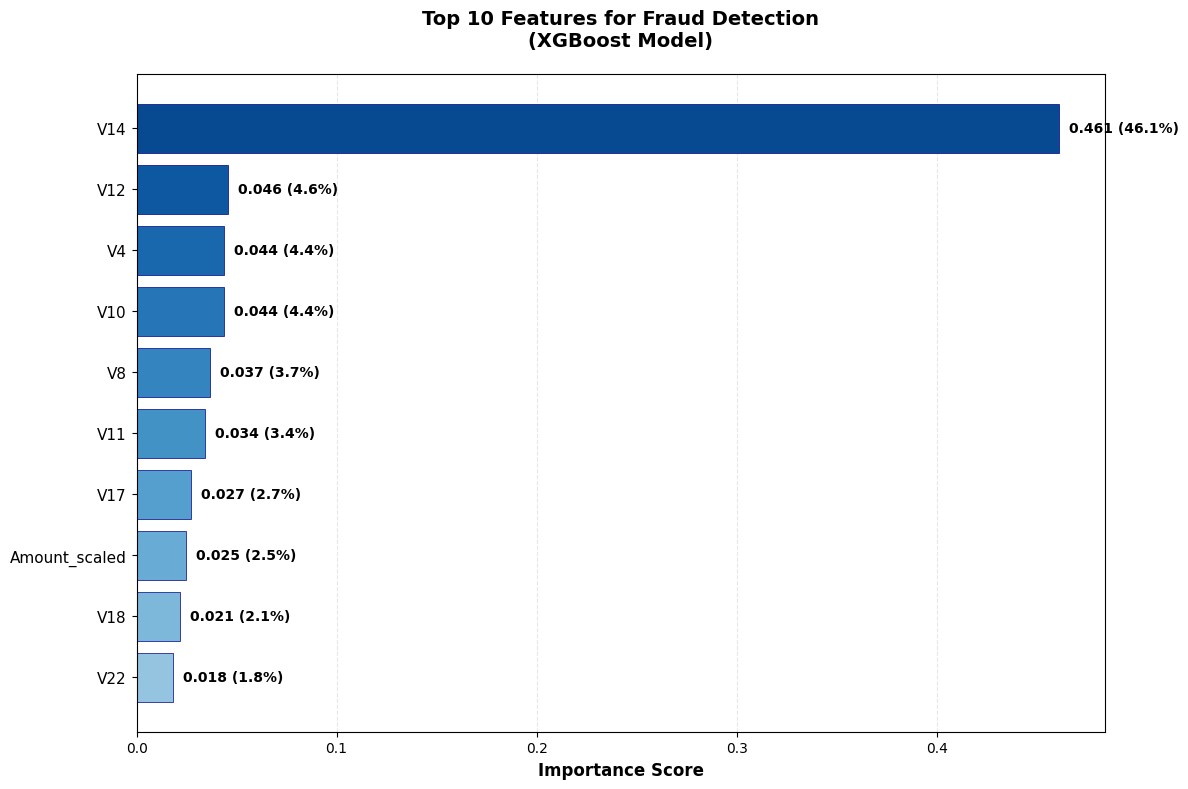

   Saved: images/feature_importance_top10.png


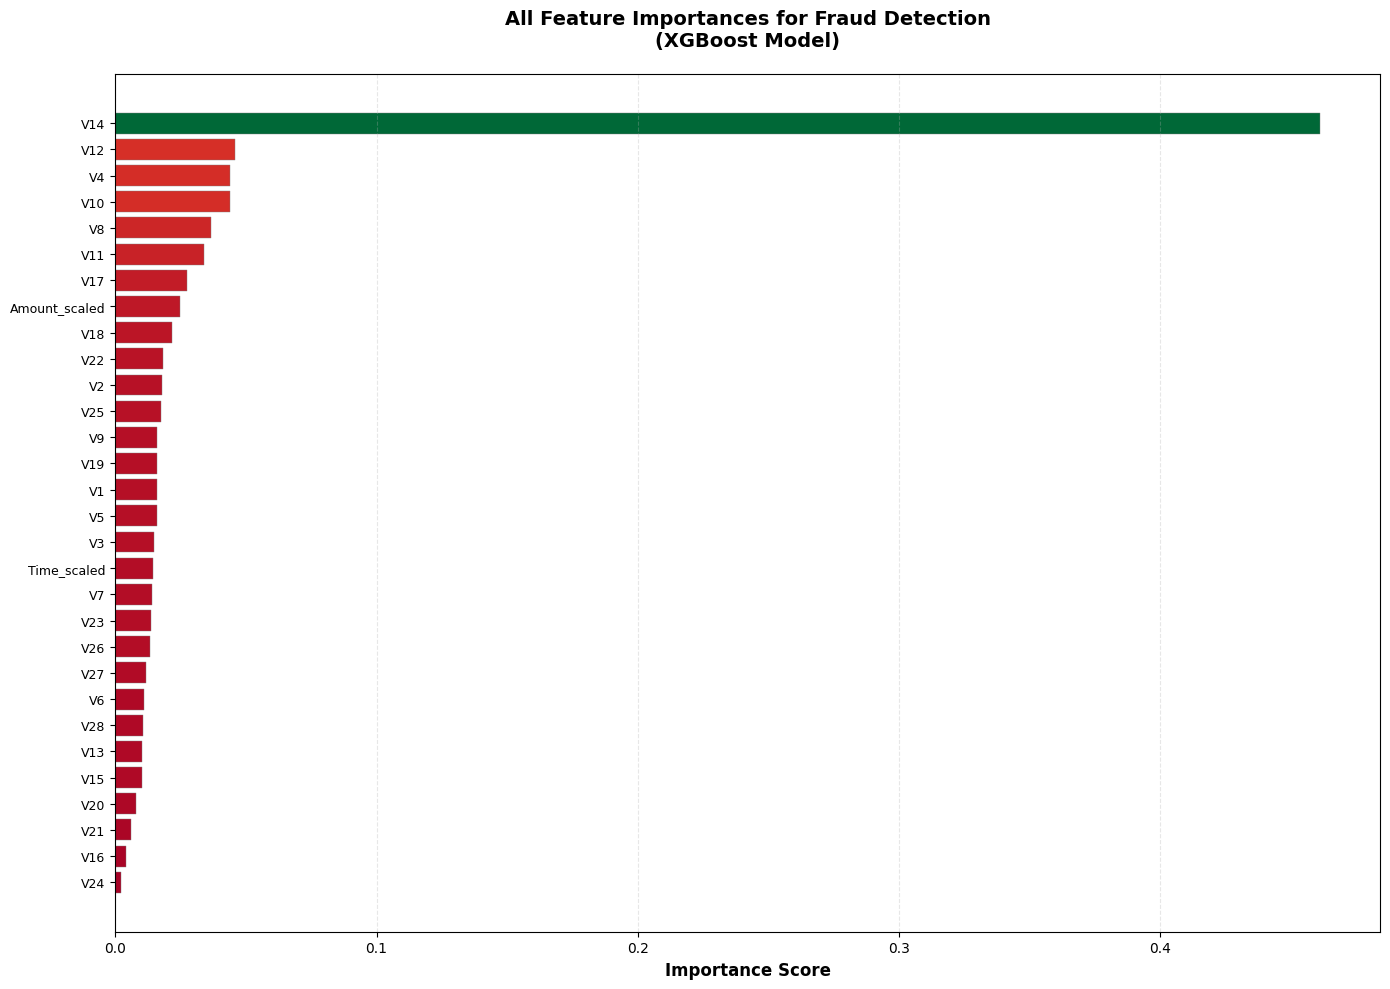

   Saved: images/feature_importance_all.png


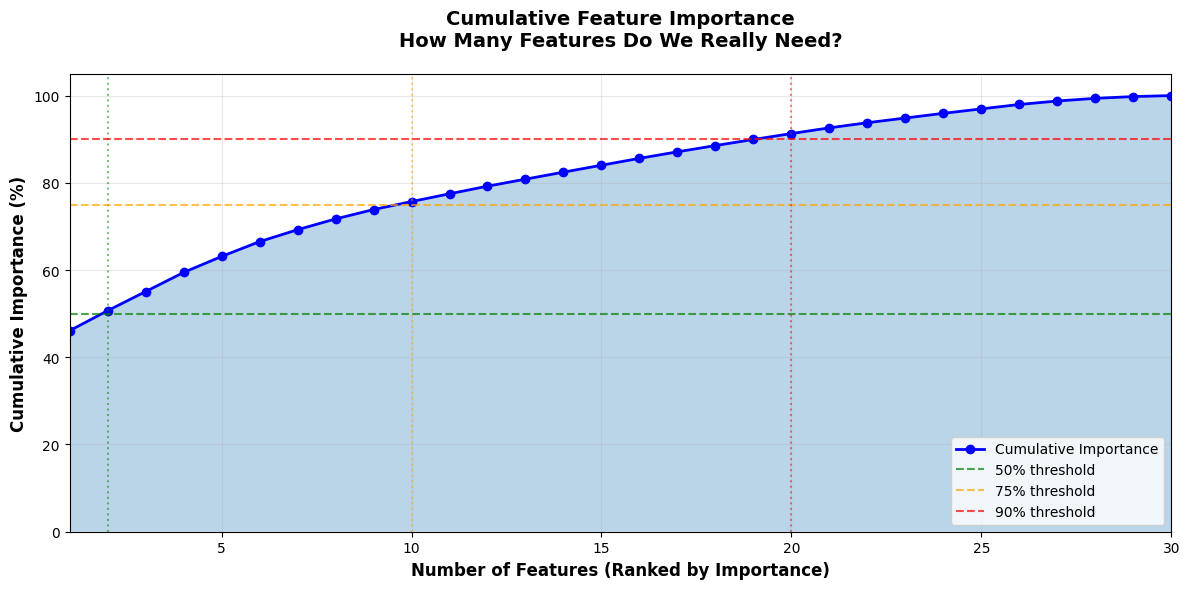

   Saved: images/feature_importance_cumulative.png

SAVING RESULTS
   Saved: models/feature_importance.csv
   Saved: results/feature_importance_analysis.json

STEP 29 COMPLETE: Feature Importance Analysis

Files created:
- images/feature_importance_top10.png
- images/feature_importance_all.png
- images/feature_importance_cumulative.png
- models/feature_importance.csv
- results/feature_importance_analysis.json



In [2]:
# =============================================================================
# STEP 29: FEATURE IMPORTANCE ANALYSIS
# =============================================================================
# What: Identify which features contribute most to fraud predictions
# Why: Demonstrates model interpretability - critical for stakeholder trust,
#      regulatory compliance, and business insights
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
from pathlib import Path

# =============================================================================
# SETUP PATHS
# =============================================================================
MODELS_DIR = Path('../models')
RESULTS_DIR = Path('../results')
IMAGES_DIR = Path('../images')
DATA_DIR = Path('../data/processed')

# Create images directory if it doesn't exist
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("STEP 29: FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

# =============================================================================
# LOAD THE BEST MODEL AND DATA
# =============================================================================
print("\nLoading best model and feature data...")

# Load the deployment model
best_model = joblib.load(MODELS_DIR / 'fraud_model_deployment.pkl')
best_model_name = "XGBoost"
print(f"   Loaded: {best_model_name}")
print(f"   Object type: {type(best_model).__name__}")

# Handle both Pipeline and raw model cases
if hasattr(best_model, 'steps'):
    print(f"   Pipeline steps: {list(best_model.named_steps.keys())}")
    actual_model = best_model.steps[-1][1]
    print(f"   Extracted model from Pipeline: {type(actual_model).__name__}")
else:
    actual_model = best_model
    print(f"   Model type: {type(actual_model).__name__}")

# Load feature names from the test data
X_test = pd.read_csv(DATA_DIR / 'X_test_scaled.csv')
feature_names = X_test.columns.tolist()
print(f"   Loaded {len(feature_names)} feature names")

# =============================================================================
# EXTRACT FEATURE IMPORTANCE
# =============================================================================
print("\n" + "=" * 70)
print("EXTRACTING FEATURE IMPORTANCE")
print("=" * 70)

# Get feature importances from the actual model
importances = actual_model.feature_importances_

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances,
    'Importance_Percent': importances * 100
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Add rank column
importance_df['Rank'] = range(1, len(importance_df) + 1)
importance_df = importance_df[['Rank', 'Feature', 'Importance', 'Importance_Percent']]

print(f"\nFeature Importance Rankings ({best_model_name})")
print("=" * 70)
print("\nTop 15 Most Important Features:")
print("-" * 50)

for idx, row in importance_df.head(15).iterrows():
    print(f"   {row['Rank']:2d}. {row['Feature']:8s} | {row['Importance']:.4f} ({row['Importance_Percent']:5.2f}%)")

print("\nBottom 5 Least Important Features:")
print("-" * 50)
for idx, row in importance_df.tail(5).iterrows():
    print(f"   {row['Rank']:2d}. {row['Feature']:8s} | {row['Importance']:.4f} ({row['Importance_Percent']:5.2f}%)")

# =============================================================================
# CUMULATIVE IMPORTANCE ANALYSIS
# =============================================================================
print("\n" + "=" * 70)
print("CUMULATIVE IMPORTANCE ANALYSIS")
print("=" * 70)

importance_df['Cumulative_Importance'] = importance_df['Importance'].cumsum()
importance_df['Cumulative_Percent'] = importance_df['Cumulative_Importance'] * 100

# Find how many features needed for different thresholds
for threshold in [0.50, 0.75, 0.90, 0.95]:
    features_needed = (importance_df['Cumulative_Importance'] <= threshold).sum() + 1
    print(f"   Features needed for {threshold*100:.0f}% importance: {features_needed} of {len(feature_names)}")

# =============================================================================
# VISUALIZATION 1: TOP 10 FEATURES
# =============================================================================
print("\n" + "=" * 70)
print("CREATING VISUALIZATIONS")
print("=" * 70)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, 10))[::-1]

fig, ax = plt.subplots(figsize=(12, 8))

top_10 = importance_df.head(10)
y_pos = range(len(top_10))

bars = ax.barh(y_pos, top_10['Importance'], color=colors, edgecolor='darkblue', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_10['Feature'], fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title(f'Top 10 Features for Fraud Detection\n({best_model_name} Model)', 
             fontsize=14, fontweight='bold', pad=20)

# Add value labels on bars
for i, (bar, val, pct) in enumerate(zip(bars, top_10['Importance'], top_10['Importance_Percent'])):
    ax.text(val + 0.005, i, f'{val:.3f} ({pct:.1f}%)', 
            va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'feature_importance_top10.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()
print("   Saved: images/feature_importance_top10.png")

# =============================================================================
# VISUALIZATION 2: ALL FEATURES
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 10))

norm_importance = importance_df['Importance'] / importance_df['Importance'].max()
colors_all = plt.cm.RdYlGn(norm_importance.values)

y_pos = range(len(importance_df))
bars = ax.barh(y_pos, importance_df['Importance'], color=colors_all, edgecolor='gray', linewidth=0.3)

ax.set_yticks(y_pos)
ax.set_yticklabels(importance_df['Feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title(f'All Feature Importances for Fraud Detection\n({best_model_name} Model)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'feature_importance_all.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("   Saved: images/feature_importance_all.png")

# =============================================================================
# VISUALIZATION 3: CUMULATIVE IMPORTANCE CURVE
# =============================================================================
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, len(importance_df) + 1), importance_df['Cumulative_Percent'], 
        'b-', linewidth=2, marker='o', markersize=6, label='Cumulative Importance')
ax.fill_between(range(1, len(importance_df) + 1), importance_df['Cumulative_Percent'], 
                alpha=0.3)

# Add threshold lines
for threshold, color in [(50, 'green'), (75, 'orange'), (90, 'red')]:
    ax.axhline(y=threshold, color=color, linestyle='--', alpha=0.7, label=f'{threshold}% threshold')
    features_at_threshold = (importance_df['Cumulative_Percent'] >= threshold).idxmax() + 1
    ax.axvline(x=features_at_threshold, color=color, linestyle=':', alpha=0.5)

ax.set_xlabel('Number of Features (Ranked by Importance)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Importance (%)', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Feature Importance\nHow Many Features Do We Really Need?', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, len(importance_df))
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(IMAGES_DIR / 'feature_importance_cumulative.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print("   Saved: images/feature_importance_cumulative.png")

# =============================================================================
# SAVE RESULTS
# =============================================================================
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save importance dataframe
importance_df.to_csv(MODELS_DIR / 'feature_importance.csv', index=False)
print("   Saved: models/feature_importance.csv")

# Save analysis as JSON
top_3 = importance_df.head(3)
top_3_total = top_3['Importance'].sum() * 100

feature_importance_analysis = {
    'model_name': best_model_name,
    'total_features': len(feature_names),
    'top_10_features': importance_df.head(10)[['Feature', 'Importance', 'Importance_Percent']].to_dict('records'),
    'cumulative_analysis': {
        'features_for_50_percent': int((importance_df['Cumulative_Importance'] <= 0.50).sum() + 1),
        'features_for_75_percent': int((importance_df['Cumulative_Importance'] <= 0.75).sum() + 1),
        'features_for_90_percent': int((importance_df['Cumulative_Importance'] <= 0.90).sum() + 1),
        'features_for_95_percent': int((importance_df['Cumulative_Importance'] <= 0.95).sum() + 1)
    },
    'key_insight': f"Top 3 features ({', '.join(top_3['Feature'].tolist())}) account for {top_3_total:.1f}% of importance",
    'interpretation_note': "V1-V28 are PCA-transformed; Amount and Time are original features"
}

with open(RESULTS_DIR / 'feature_importance_analysis.json', 'w') as f:
    json.dump(feature_importance_analysis, f, indent=2)
print("   Saved: results/feature_importance_analysis.json")

print("\n" + "=" * 70)
print("STEP 29 COMPLETE: Feature Importance Analysis")
print("=" * 70)
print("""
Files created:
- images/feature_importance_top10.png
- images/feature_importance_all.png
- images/feature_importance_cumulative.png
- models/feature_importance.csv
- results/feature_importance_analysis.json
""")

In [7]:
# ============================================================================
# PHASE 6: ANALYSIS AND VISUALIZATION
# STEP 30: CONFUSION MATRIX ANALYSIS
# ============================================================================
# Purpose: Create detailed confusion matrix visualization with business context
# Input: final_test_results.pkl (from Step 23)
# Output: confusion_matrix.png, confusion_matrix_analysis.json
# ============================================================================
# 
# WHY THIS STEP MATTERS:
# The confusion matrix is the "truth table" of your model - it shows exactly
# what the model gets right and wrong. In fraud detection, understanding these
# tradeoffs is critical because:
#   - False Positives (FP) = Legitimate transactions blocked = angry customers
#   - False Negatives (FN) = Fraud that slips through = direct financial loss
# 
# This visualization will be one of your most-discussed portfolio pieces
# because it directly shows business impact.
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
from datetime import datetime
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("=" * 70)
print("STEP 30: CONFUSION MATRIX ANALYSIS")
print("=" * 70)
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# ----------------------------------------------------------------------------
# SECTION 1: Load Your Test Results
# ----------------------------------------------------------------------------
# We're loading the results you saved in Step 23 (Final Test Evaluation)
# This ensures we're analyzing the SAME predictions consistently

print("\nLoading test results...")

try:
    # Load final test results from Step 23
    with open('../results/final_test_results.pkl', 'rb') as f:
        test_results = pickle.load(f)
    print("Loaded ../results/final_test_results.pkl")
    
    # Extract the confusion matrix
    # Your Step 23 saved this as a 2x2 numpy array
    cm = np.array(test_results['confusion_matrix'])
    
    # Extract individual values
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix Values (at default 0.5 threshold):")
    print(f"   True Negatives (TN):  {tn:,}")
    print(f"   False Positives (FP): {fp:,}")
    print(f"   False Negatives (FN): {fn:,}")
    print(f"   True Positives (TP):  {tp:,}")
    
except FileNotFoundError:
    print("Error: ../results/final_test_results.pkl not found")
    print("   Please run Step 23 (Final Test Evaluation) first")
    raise

# Your best model name (XGBoost based on your project)
best_model_name = "XGBoost"

# ----------------------------------------------------------------------------
# SECTION 2: Calculate Detailed Metrics
# ----------------------------------------------------------------------------
# These metrics help you understand model performance from different angles

print("\n" + "=" * 70)
print("DETAILED PERFORMANCE METRICS (Default 0.5 Threshold)")
print("=" * 70)

# Total transactions in test set
total = tn + fp + fn + tp
total_legitimate = tn + fp
total_fraud = fn + tp

# Key rates
accuracy = (tn + tp) / total
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Also called Sensitivity or TPR
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Also called TNR

# Error rates
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0  # Also called FPR or Fall-out
false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else 0  # Also called FNR or Miss Rate

print(f"\nCore Performance Metrics:")
print(f"   Accuracy:    {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision:   {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall:      {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1-Score:    {f1:.4f}")
print(f"   Specificity: {specificity:.4f} ({specificity*100:.2f}%)")

print(f"\nError Analysis:")
print(f"   False Positive Rate: {false_positive_rate:.4f} ({false_positive_rate*100:.2f}%)")
print(f"   False Negative Rate: {false_negative_rate:.4f} ({false_negative_rate*100:.2f}%)")
print(f"   Total Errors: {fp + fn:,} out of {total:,}")

# ----------------------------------------------------------------------------
# SECTION 3: Create Professional Confusion Matrix Visualization
# ----------------------------------------------------------------------------
# This creates a publication-quality visualization suitable for your portfolio

print("\n" + "=" * 70)
print("CREATING CONFUSION MATRIX VISUALIZATION")
print("=" * 70)

# Set up the figure with a clean, professional style
fig, ax = plt.subplots(figsize=(12, 10))

# Create the heatmap with counts
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Predicted\nLegitimate', 'Predicted\nFraud'],
            yticklabels=['Actually\nLegitimate', 'Actually\nFraud'],
            cbar_kws={'label': 'Transaction Count', 'shrink': 0.8},
            linewidths=3, linecolor='white')

# Add custom annotations with counts and percentages
annotations = [
    [f'TN\n{tn:,}\n({tn/total*100:.2f}%)', f'FP\n{fp:,}\n({fp/total*100:.2f}%)'],
    [f'FN\n{fn:,}\n({fn/total*100:.2f}%)', f'TP\n{tp:,}\n({tp/total*100:.2f}%)']
]

for i in range(2):
    for j in range(2):
        # Choose text color based on cell value
        text_color = 'white' if cm[i, j] > total * 0.1 else 'black'
        ax.text(j + 0.5, i + 0.5, annotations[i][j],
                ha='center', va='center', fontsize=14, fontweight='bold',
                color=text_color)

# Add title and labels
ax.set_title(f'Confusion Matrix Analysis (Threshold = 0.5)\n{best_model_name} - Credit Card Fraud Detection',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Predicted Class', fontsize=14, fontweight='bold', labelpad=15)
ax.set_ylabel('Actual Class', fontsize=14, fontweight='bold', labelpad=15)

# Adjust tick labels
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()

# Save the visualization
plt.savefig('../images/confusion_matrix.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("Saved: ../images/confusion_matrix.png")

plt.close()

# ----------------------------------------------------------------------------
# SECTION 4: Create Enhanced Confusion Matrix with Business Context
# ----------------------------------------------------------------------------
# This version adds business interpretation to each quadrant

print("\nCreating enhanced confusion matrix with business context...")

fig, ax = plt.subplots(figsize=(14, 11))

# Create base heatmap
sns.heatmap(cm, annot=False, fmt='d', cmap='RdYlGn_r', ax=ax,
            xticklabels=['', ''],
            yticklabels=['', ''],
            cbar=False,
            linewidths=4, linecolor='white',
            vmin=0, vmax=cm.max())

# Custom annotations with business context
business_annotations = [
    # TN: True Negatives
    {
        'title': 'TRUE NEGATIVE',
        'count': f'{tn:,}',
        'percent': f'{tn/total*100:.2f}%',
        'business': 'Happy Customers'
    },
    # FP: False Positives
    {
        'title': 'FALSE POSITIVE',
        'count': f'{fp:,}',
        'percent': f'{fp/total*100:.2f}%',
        'business': 'Customer Friction'
    },
    # FN: False Negatives
    {
        'title': 'FALSE NEGATIVE',
        'count': f'{fn:,}',
        'percent': f'{fn/total*100:.2f}%',
        'business': 'Direct Loss'
    },
    # TP: True Positives
    {
        'title': 'TRUE POSITIVE',
        'count': f'{tp:,}',
        'percent': f'{tp/total*100:.2f}%',
        'business': 'Loss Prevented'
    }
]

# Position annotations
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for idx, (i, j) in enumerate(positions):
    ann = business_annotations[idx]
    
    # Title
    ax.text(j + 0.5, i + 0.2, ann['title'],
            ha='center', va='center', fontsize=11, fontweight='bold',
            color='white')
    
    # Count (large)
    ax.text(j + 0.5, i + 0.45, ann['count'],
            ha='center', va='center', fontsize=22, fontweight='bold',
            color='white')
    
    # Percentage
    ax.text(j + 0.5, i + 0.65, f"({ann['percent']})",
            ha='center', va='center', fontsize=12,
            color='white')
    
    # Business meaning
    ax.text(j + 0.5, i + 0.85, ann['business'],
            ha='center', va='center', fontsize=10,
            color='white', style='italic')

# Add axis labels
ax.set_xlabel('\nModel Prediction', fontsize=14, fontweight='bold')
ax.set_ylabel('Actual Outcome\n', fontsize=14, fontweight='bold')

# Add custom tick labels
ax.set_xticks([0.5, 1.5])
ax.set_xticklabels(['Predicted LEGITIMATE', 'Predicted FRAUD'], fontsize=12, fontweight='bold')
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(['Actually LEGITIMATE', 'Actually FRAUD'], fontsize=12, fontweight='bold')

# Title
ax.set_title(f'Confusion Matrix: Business Impact Analysis (Threshold = 0.5)\n{best_model_name} Fraud Detection Model',
             fontsize=16, fontweight='bold', pad=20)

# Add summary box
summary_text = (
    f"Total Test Transactions: {total:,}\n"
    f"Fraud Detection Rate (Recall): {recall*100:.1f}%\n"
    f"Precision: {precision*100:.1f}%\n"
    f"False Positive Rate: {false_positive_rate*100:.2f}%"
)

props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='gray', alpha=0.9)
ax.text(1.02, 0.5, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='center', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('../images/confusion_matrix_business.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("Saved: ../images/confusion_matrix_business.png")

plt.close()

# ----------------------------------------------------------------------------
# SECTION 5: THRESHOLD ANALYSIS
# ----------------------------------------------------------------------------
# Analyzing how different classification thresholds affect model performance
# Default threshold is 0.5, but we can optimize based on business needs

print("\n" + "=" * 70)
print("THRESHOLD ANALYSIS")
print("=" * 70)

print("\nLoading model and test data for threshold analysis...")

# Load the XGBoost model and test data
with open('../models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)
print("Loaded: ../models/xgboost_model.pkl")

X_test = pd.read_csv('../data/processed/x_test_scaled.csv')
print("Loaded: ../data/processed/x_test_scaled.csv")

y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()
print("Loaded: ../data/processed/y_test.csv")

# Get predicted probabilities
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
print(f"Generated predictions for {len(y_test):,} test samples")

# Define thresholds to analyze
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Business cost assumptions
avg_fraud_amount = 150
cost_per_false_positive = 25
cost_per_missed_fraud = avg_fraud_amount

print(f"\nAnalyzing {len(thresholds)} different thresholds...")
print("-" * 70)

# Store results for each threshold
threshold_results = []

for thresh in thresholds:
    # Apply threshold to get predictions
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    
    # Calculate confusion matrix
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    tn_t, fp_t, fn_t, tp_t = cm_thresh.ravel()
    
    # Calculate metrics
    precision_t = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
    recall_t = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
    f1_t = 2 * (precision_t * recall_t) / (precision_t + recall_t) if (precision_t + recall_t) > 0 else 0
    fpr_t = fp_t / (fp_t + tn_t) if (fp_t + tn_t) > 0 else 0
    
    # Calculate business impact
    fp_cost = fp_t * cost_per_false_positive
    fn_cost = fn_t * cost_per_missed_fraud
    total_cost_t = fp_cost + fn_cost
    fraud_prevented_t = tp_t * avg_fraud_amount
    net_value_t = fraud_prevented_t - total_cost_t
    
    # Store results
    threshold_results.append({
        'threshold': thresh,
        'tn': tn_t,
        'fp': fp_t,
        'fn': fn_t,
        'tp': tp_t,
        'precision': precision_t,
        'recall': recall_t,
        'f1_score': f1_t,
        'fpr': fpr_t,
        'fp_cost': fp_cost,
        'fn_cost': fn_cost,
        'total_cost': total_cost_t,
        'fraud_prevented': fraud_prevented_t,
        'net_value': net_value_t
    })

# Create DataFrame for easy viewing
threshold_df = pd.DataFrame(threshold_results)

# Display threshold comparison table
print("\nThreshold Comparison Table:")
print("=" * 70)
print(f"{'Thresh':<8} {'Recall':<10} {'Precision':<10} {'F1':<8} {'FP':<8} {'FN':<6} {'Net Value':<12}")
print("-" * 70)

for _, row in threshold_df.iterrows():
    print(f"{row['threshold']:<8.1f} {row['recall']*100:<10.1f} {row['precision']*100:<10.1f} "
          f"{row['f1_score']:<8.4f} {row['fp']:<8.0f} {row['fn']:<6.0f} ${row['net_value']:<11,.0f}")

# Find optimal thresholds for different objectives
best_f1_idx = threshold_df['f1_score'].idxmax()
best_f1_thresh = threshold_df.loc[best_f1_idx, 'threshold']

best_recall_idx = threshold_df['recall'].idxmax()
best_recall_thresh = threshold_df.loc[best_recall_idx, 'threshold']

best_value_idx = threshold_df['net_value'].idxmax()
best_value_thresh = threshold_df.loc[best_value_idx, 'threshold']

print("\n" + "=" * 70)
print("OPTIMAL THRESHOLDS BY OBJECTIVE")
print("=" * 70)

print(f"\nBest F1-Score: Threshold = {best_f1_thresh}")
print(f"   F1-Score: {threshold_df.loc[best_f1_idx, 'f1_score']:.4f}")
print(f"   Recall: {threshold_df.loc[best_f1_idx, 'recall']*100:.1f}%")
print(f"   Precision: {threshold_df.loc[best_f1_idx, 'precision']*100:.1f}%")

print(f"\nBest Recall (Catch Most Fraud): Threshold = {best_recall_thresh}")
print(f"   Recall: {threshold_df.loc[best_recall_idx, 'recall']*100:.1f}%")
print(f"   Precision: {threshold_df.loc[best_recall_idx, 'precision']*100:.1f}%")
print(f"   False Positives: {threshold_df.loc[best_recall_idx, 'fp']:,.0f}")

print(f"\nBest Net Value (Business Optimal): Threshold = {best_value_thresh}")
print(f"   Net Value: ${threshold_df.loc[best_value_idx, 'net_value']:,.0f}")
print(f"   Recall: {threshold_df.loc[best_value_idx, 'recall']*100:.1f}%")
print(f"   Precision: {threshold_df.loc[best_value_idx, 'precision']*100:.1f}%")

# ----------------------------------------------------------------------------
# SECTION 6: Threshold Analysis Visualization
# ----------------------------------------------------------------------------

print("\nCreating threshold analysis visualization...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Precision vs Recall at different thresholds
ax1 = axes[0, 0]
ax1.plot(threshold_df['threshold'], threshold_df['recall'] * 100, 'b-o', linewidth=2, markersize=8, label='Recall')
ax1.plot(threshold_df['threshold'], threshold_df['precision'] * 100, 'r-s', linewidth=2, markersize=8, label='Precision')
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax1.set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
ax1.set_title('Precision and Recall vs Threshold', fontsize=14, fontweight='bold')
ax1.legend(loc='center right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 105])

# Plot 2: F1-Score vs Threshold
ax2 = axes[0, 1]
ax2.plot(threshold_df['threshold'], threshold_df['f1_score'], 'g-o', linewidth=2, markersize=8)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
ax2.axvline(x=best_f1_thresh, color='green', linestyle='--', alpha=0.7, label=f'Best F1 ({best_f1_thresh})')
ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax2.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax2.set_title('F1-Score vs Threshold', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim([0, 1])

# Plot 3: False Positives and False Negatives vs Threshold
ax3 = axes[1, 0]
ax3.plot(threshold_df['threshold'], threshold_df['fp'], 'r-o', linewidth=2, markersize=8, label='False Positives')
ax3.plot(threshold_df['threshold'], threshold_df['fn'], 'b-s', linewidth=2, markersize=8, label='False Negatives')
ax3.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
ax3.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax3.set_ylabel('Count', fontsize=12, fontweight='bold')
ax3.set_title('Error Counts vs Threshold', fontsize=14, fontweight='bold')
ax3.legend(loc='center right', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0, 1])

# Plot 4: Net Business Value vs Threshold
ax4 = axes[1, 1]
colors = ['green' if v >= 0 else 'red' for v in threshold_df['net_value']]
ax4.bar(threshold_df['threshold'], threshold_df['net_value'], width=0.08, color=colors, alpha=0.7, edgecolor='black')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.axvline(x=0.5, color='gray', linestyle='--', alpha=0.7, label='Default (0.5)')
ax4.axvline(x=best_value_thresh, color='blue', linestyle='--', alpha=0.7, label=f'Best Value ({best_value_thresh})')
ax4.set_xlabel('Threshold', fontsize=12, fontweight='bold')
ax4.set_ylabel('Net Value ($)', fontsize=12, fontweight='bold')
ax4.set_title('Net Business Value vs Threshold', fontsize=14, fontweight='bold')
ax4.legend(loc='best', fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_xlim([0, 1])

plt.suptitle(f'Threshold Analysis - {best_model_name} Fraud Detection Model', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/threshold_analysis.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("Saved: ../images/threshold_analysis.png")

plt.close()

# ----------------------------------------------------------------------------
# SECTION 7: Detailed Breakdown and Business Impact (at default 0.5)
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("CONFUSION MATRIX BREAKDOWN (Default 0.5 Threshold)")
print("=" * 70)

print(f"\nTransaction Classification Summary:")
print("-" * 50)

# True Negatives
print(f"\nTRUE NEGATIVES (TN): {tn:,}")
print(f"   What it means: Legitimate transactions correctly approved")
print(f"   Percentage: {tn/total*100:.2f}% of all test transactions")
print(f"   Business impact: Seamless customer experience")
print(f"   Of all legitimate transactions: {tn/total_legitimate*100:.2f}% handled correctly")

# False Positives
print(f"\nFALSE POSITIVES (FP): {fp:,}")
print(f"   What it means: Legitimate transactions wrongly flagged as fraud")
print(f"   Percentage: {fp/total*100:.2f}% of all test transactions")
print(f"   Business impact: Customer inconvenience, investigation costs")
print(f"   False Positive Rate: {false_positive_rate*100:.2f}%")
print(f"   (For every 1,000 legitimate transactions, ~{int(false_positive_rate*1000)} are wrongly blocked)")

# False Negatives
print(f"\nFALSE NEGATIVES (FN): {fn:,}")
print(f"   What it means: Fraudulent transactions that slipped through")
print(f"   Percentage: {fn/total*100:.2f}% of all test transactions")
print(f"   Business impact: DIRECT FINANCIAL LOSS")
print(f"   False Negative Rate: {false_negative_rate*100:.2f}%")
print(f"   Of all fraud attempts: {fn/total_fraud*100:.1f}% went undetected")

# True Positives
print(f"\nTRUE POSITIVES (TP): {tp:,}")
print(f"   What it means: Fraudulent transactions correctly caught")
print(f"   Percentage: {tp/total*100:.2f}% of all test transactions")
print(f"   Business impact: FRAUD PREVENTED")
print(f"   Fraud Detection Rate (Recall): {recall*100:.1f}%")
print(f"   Of all fraud attempts: {tp/total_fraud*100:.1f}% were caught")

# ----------------------------------------------------------------------------
# SECTION 8: Business Impact Calculations
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("BUSINESS IMPACT ANALYSIS (Default 0.5 Threshold)")
print("=" * 70)

# Calculate costs
cost_of_false_positives = fp * cost_per_false_positive
cost_of_missed_frauds = fn * cost_per_missed_fraud
total_cost = cost_of_false_positives + cost_of_missed_frauds

# Calculate value
fraud_value_protected = tp * avg_fraud_amount

print(f"\nCost Analysis (Based on Industry Estimates):")
print("-" * 50)
print(f"   Assumptions:")
print(f"   - Average fraud transaction: ${avg_fraud_amount}")
print(f"   - Cost per false positive: ${cost_per_false_positive}")
print(f"     (Investigation time + customer service)")
print(f"   - Cost per missed fraud: ${cost_per_missed_fraud}")
print(f"     (Direct financial loss)")

print(f"\n   Calculated Impact:")
print(f"   - False Positive Costs: ${cost_of_false_positives:,.2f}")
print(f"     ({fp} x ${cost_per_false_positive})")
print(f"   - Missed Fraud Losses: ${cost_of_missed_frauds:,.2f}")
print(f"     ({fn} x ${cost_per_missed_fraud})")
print(f"   - Total Error Cost: ${total_cost:,.2f}")

print(f"\n   Value Generated:")
print(f"   - Fraud Prevented: ${fraud_value_protected:,.2f}")
print(f"     ({tp} x ${avg_fraud_amount})")
print(f"   - Net Value: ${fraud_value_protected - total_cost:,.2f}")

# ROI calculation
if total_cost > 0:
    roi = (fraud_value_protected - total_cost) / total_cost * 100
    print(f"   - ROI: {roi:.1f}%")

# ----------------------------------------------------------------------------
# SECTION 9: Error Analysis - Deep Dive
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("ERROR ANALYSIS")
print("=" * 70)

total_errors = fp + fn
correct_predictions = tn + tp

print(f"\nPrediction Quality:")
print(f"   Correct Predictions: {correct_predictions:,} ({correct_predictions/total*100:.2f}%)")
print(f"   Total Errors: {total_errors:,} ({total_errors/total*100:.2f}%)")

print(f"\nError Composition:")
print(f"   False Positives: {fp:,} ({fp/total_errors*100:.1f}% of all errors)")
print(f"   False Negatives: {fn:,} ({fn/total_errors*100:.1f}% of all errors)")

# Business priority analysis
print(f"\nBusiness Priority Analysis:")
print(f"   In fraud detection, False Negatives are typically MORE costly than False Positives")
print(f"   because a missed fraud = direct financial loss")
print(f"   ")
if fn > 0:
    print(f"   Your model's FN:FP ratio = {fn}:{fp} = 1:{fp/fn:.1f}")
    print(f"   ")
    print(f"   Interpretation: For every fraud that slips through,")
    print(f"   your model creates ~{fp/fn:.0f} false alarms")
else:
    print(f"   Your model's FN:FP ratio = {fn}:{fp}")
    print(f"   Perfect fraud detection!")

# ----------------------------------------------------------------------------
# SECTION 10: Key Performance Indicators Summary
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("=" * 70)

print(f"\nCritical Metrics for Fraud Detection (at 0.5 threshold):")
print("-" * 50)

kpis = {
    'Fraud Detection Rate (Recall/Sensitivity)': f'{recall*100:.1f}%',
    'Precision (When we flag fraud, how often correct)': f'{precision*100:.1f}%',
    'False Positive Rate (Legitimate flagged as fraud)': f'{false_positive_rate*100:.2f}%',
    'False Negative Rate (Fraud missed)': f'{false_negative_rate*100:.2f}%',
    'Specificity (Legitimate correctly approved)': f'{specificity*100:.2f}%',
    'Overall Accuracy': f'{accuracy*100:.2f}%',
    'F1-Score (Balance of Precision & Recall)': f'{f1:.4f}'
}

for metric, value in kpis.items():
    print(f"   - {metric}: {value}")

# ----------------------------------------------------------------------------
# SECTION 11: Save Results
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Compile all metrics into a dictionary
confusion_matrix_analysis = {
    'model_name': best_model_name,
    'timestamp': datetime.now().isoformat(),
    'default_threshold': 0.5,
    'confusion_matrix': {
        'true_negatives': int(tn),
        'false_positives': int(fp),
        'false_negatives': int(fn),
        'true_positives': int(tp),
        'total_transactions': int(total)
    },
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'specificity': float(specificity),
        'false_positive_rate': float(false_positive_rate),
        'false_negative_rate': float(false_negative_rate)
    },
    'class_breakdown': {
        'total_legitimate': int(total_legitimate),
        'total_fraud': int(total_fraud),
        'fraud_rate': float(total_fraud / total * 100)
    },
    'business_impact': {
        'assumptions': {
            'avg_fraud_amount_usd': avg_fraud_amount,
            'cost_per_false_positive_usd': cost_per_false_positive,
            'cost_per_missed_fraud_usd': cost_per_missed_fraud
        },
        'calculated_costs': {
            'false_positive_costs_usd': float(cost_of_false_positives),
            'missed_fraud_losses_usd': float(cost_of_missed_frauds),
            'total_error_cost_usd': float(total_cost)
        },
        'value_generated': {
            'fraud_prevented_usd': float(fraud_value_protected),
            'net_value_usd': float(fraud_value_protected - total_cost)
        }
    },
    'threshold_analysis': {
        'thresholds_tested': thresholds,
        'best_f1_threshold': float(best_f1_thresh),
        'best_recall_threshold': float(best_recall_thresh),
        'best_business_value_threshold': float(best_value_thresh),
        'detailed_results': threshold_df.to_dict(orient='records')
    }
}

# Save to JSON
with open('../results/confusion_matrix_analysis.json', 'w') as f:
    json.dump(confusion_matrix_analysis, f, indent=2)
print("Saved: ../results/confusion_matrix_analysis.json")

# Save to CSV for easy reference
cm_df = pd.DataFrame({
    'Metric': list(kpis.keys()),
    'Value': list(kpis.values())
})
cm_df.to_csv('../results/confusion_matrix_metrics.csv', index=False)
print("Saved: ../results/confusion_matrix_metrics.csv")

# Save threshold analysis to CSV
threshold_df.to_csv('../results/threshold_analysis.csv', index=False)
print("Saved: ../results/threshold_analysis.csv")

# ----------------------------------------------------------------------------
# FINAL SUMMARY
# ----------------------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 30 COMPLETE - CONFUSION MATRIX ANALYSIS")
print("=" * 70)

print(f"\nFiles Created:")
print(f"   - ../images/confusion_matrix.png (Standard visualization)")
print(f"   - ../images/confusion_matrix_business.png (With business context)")
print(f"   - ../images/threshold_analysis.png (Threshold comparison charts)")
print(f"   - ../results/confusion_matrix_analysis.json (Complete analysis data)")
print(f"   - ../results/confusion_matrix_metrics.csv (Key metrics table)")
print(f"   - ../results/threshold_analysis.csv (Threshold comparison data)")

print(f"\nKey Results (at default 0.5 threshold):")
print(f"   - Fraud Detection Rate: {recall*100:.1f}%")
print(f"   - False Positive Rate: {false_positive_rate*100:.2f}%")
print(f"   - Precision: {precision*100:.1f}%")
print(f"   - Net Value Generated: ${fraud_value_protected - total_cost:,.2f}")

print(f"\nThreshold Analysis Findings:")
print(f"   - Best F1-Score at threshold: {best_f1_thresh}")
print(f"   - Best Recall at threshold: {best_recall_thresh}")
print(f"   - Best Business Value at threshold: {best_value_thresh}")

print(f"\nWhat You Learned:")
print(f"   - How to interpret confusion matrix in business context")
print(f"   - Tradeoff between precision and recall")
print(f"   - How threshold selection affects model performance")
print(f"   - How to optimize threshold based on business objectives")

print(f"\nCongratulations! You have completed Phase 6: Analysis and Visualization!")
print(f"Next up: Phase 7 - Web Application Development")

print(f"\nCompleted: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

STEP 30: CONFUSION MATRIX ANALYSIS
Started: 2026-06-05 20:13:02

Loading test results...
Loaded ../results/final_test_results.pkl

Confusion Matrix Values (at default 0.5 threshold):
   True Negatives (TN):  56,044
   False Positives (FP): 607
   False Negatives (FN): 13
   True Positives (TP):  82

DETAILED PERFORMANCE METRICS (Default 0.5 Threshold)

Core Performance Metrics:
   Accuracy:    0.9891 (98.91%)
   Precision:   0.1190 (11.90%)
   Recall:      0.8632 (86.32%)
   F1-Score:    0.2092
   Specificity: 0.9893 (98.93%)

Error Analysis:
   False Positive Rate: 0.0107 (1.07%)
   False Negative Rate: 0.1368 (13.68%)
   Total Errors: 620 out of 56,746

CREATING CONFUSION MATRIX VISUALIZATION
Saved: ../images/confusion_matrix.png

Creating enhanced confusion matrix with business context...
Saved: ../images/confusion_matrix_business.png

THRESHOLD ANALYSIS

Loading model and test data for threshold analysis...
Loaded: ../models/xgboost_model.pkl
Loaded: ../data/processed/x_test_scaled